In [1]:
import numpy as np

import pymc as pm
import arviz as az

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
prior_a = 1.
prior_b = 1.

# observed data
k = 3  # number of tea drinkers
n = 5  # number of people surveyed

In [3]:
with pm.Model() as model:
    p = pm.Beta("p", alpha=prior_a, beta=prior_b)
    likelihood = pm.Binomial("k", n=n, p=p, observed=k)

    samples = pm.sample(random_seed=0)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


In [4]:
az.summary(samples, var_names=["p"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.571,0.177,0.241,0.883,0.004,0.002,1768.0,2828.0,1.0


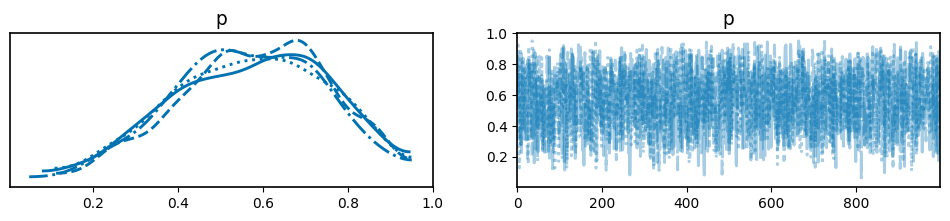

In [5]:
az.plot_trace(samples, var_names=["p"])
plt.show()

Sampling: [k]


/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

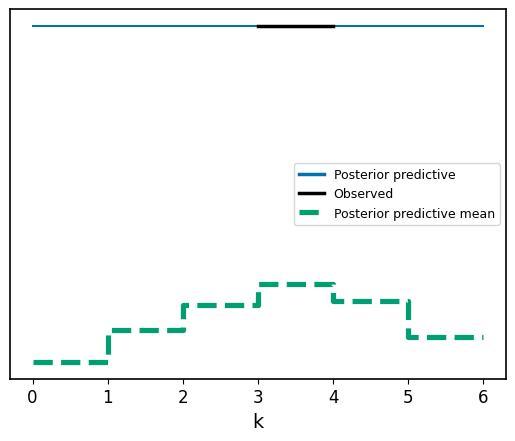

In [6]:
with model:
    ppc = pm.sample_posterior_predictive(samples, var_names=["k"])

az.plot_ppc(ppc)
plt.show()